In [2]:
import httpx
import os
import json
import time
import pandas as pd
from client_v1.settings import EmmRetrieversSettings
from client_v1.jrc_openai import JRCChatOpenAI
from client_v1.formatting_utils import fixed_width_wrap, format_docs, format_doc_minimal
from langchain_core.prompts import ChatPromptTemplate
from utils import iso3_to_iso2, generate_date_ranges, process_documents, add_sections_as_columns, plot_cgraph, plot_factsheet_clean
from openai import OpenAI
from httpx import ReadTimeout
from utils import process_graph, process_storyline, custom_sum, extract_disaster_info
from llm_utils import ensemble_graph
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [3]:
distory = pd.read_csv("./data/DisasterStory.csv")

In [4]:
distory.head()

,DisNo.,Disaster Type,Country,Locations,nNews,start_dt,key information,severity,key drivers,"main impacts, exposure, and vulnerability",likelihood of multi-hazard risks,best practices for managing this risk,recommendations and supportive measures for recovery,llama graph
0,2014-0090-MLI,Epidemic,Mali,"Bamako, Kayes",18,2014-10-24,"An Ebola outbreak occurred in Mali, specifical...",High,The main cause of the disaster was the importa...,Fatalities: At least 2 confirmed deaths (the 2...,"Unknown, but the outbreak highlighted the risk...",Aggressive contact tracing and isolation of su...,Continued surveillance and monitoring of conta...,"[('ebola virus', 'causes', 'outbreak'), ('outb..."
1,2014-0119-TZA,Flood,United Republic of Tanzania,"Kilosa, Morogoro, Dodoma, Dumila",1,2014-04-18,A flood disaster occurred in the United Republ...,High (due to the significant impact on transpo...,Unknown (the main causes of the flood disaster...,The flood resulted in economic expenditure of ...,Unknown (there is no information provided abou...,Unknown (effective prevention and mitigation s...,Unknown (guidelines for aid and rebuilding are...,"[('flood', 'causes', 'infrastructure damage'),..."
2,2014-0121-KOR,Water,Republic of Korea,"Incheon, Jeju, Mokpo, Ansan, Seoul, Jindo, Sou...",12,2014-04-16,A ferry disaster occurred in the waters off th...,High,The main causes of the disaster include overlo...,The disaster resulted in at least 275 fataliti...,Unknown,Effective prevention and mitigation strategies...,The government has revoked the operating licen...,"[('overloading', 'causes', 'instability'), ('m..."
3,2014-0125-PAK,Road,Pakistan,"Sukkur, Pano Akil, Sindh, Dera Ghazi Khan, Rah...",4,2014-04-20,A road accident occurred in Pakistan's south S...,High,The main cause of the disaster was the collisi...,"Fatalities: At least 41 people were killed, wi...",Unknown,Unknown,"The government announced Rs25,000 for each of ...","[('collision', 'causes', 'fatalities'), ('coll..."
4,2014-0126-USA,Storm,United States of America,NaN,1,2014-04-27,A severe storm occurred in the United States o...,High,"likelihood of multi-hazard risks, best practic...","The storm resulted in at least 39 fatalities, ...",Unknown,Unknown,Unknown Note: The information provided only g...,"[('severe storm', 'causes', 'tornadoes'), ('to..."


In [5]:
source, relations, target = list(zip(*eval(distory[distory["DisNo."]=="2024-0649-YEM"]["llama graph"].iloc[0])))
kg_df = pd.DataFrame({'source': source, 'target': target, 'edge': relations})

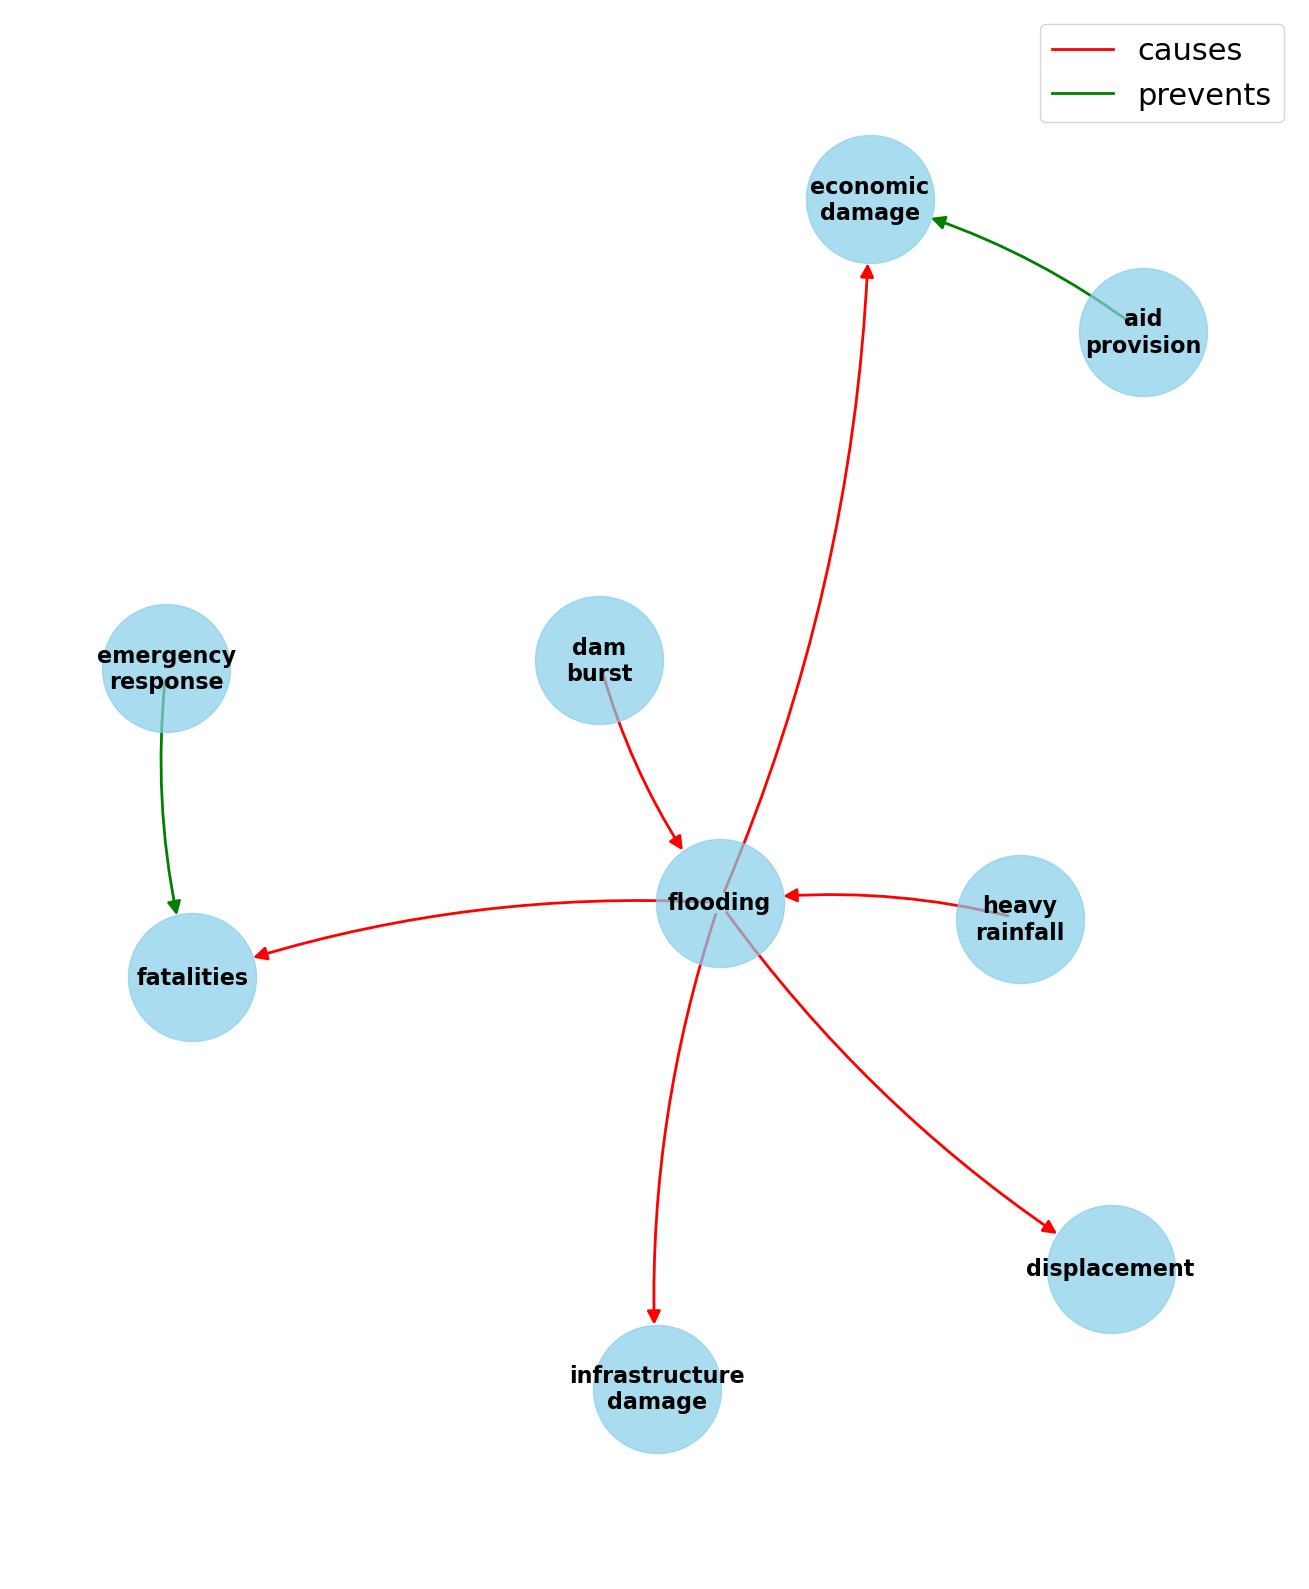

In [6]:
plot_cgraph(kg_df)

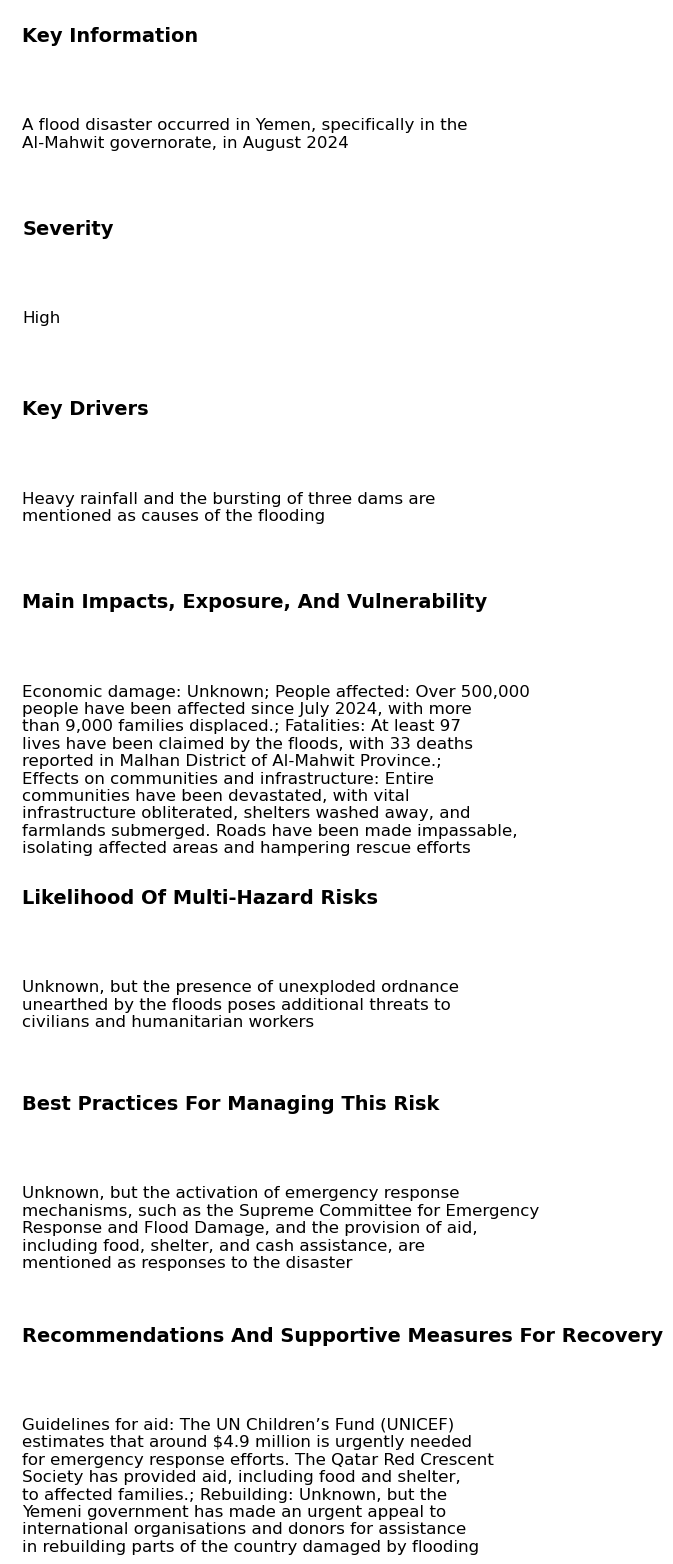

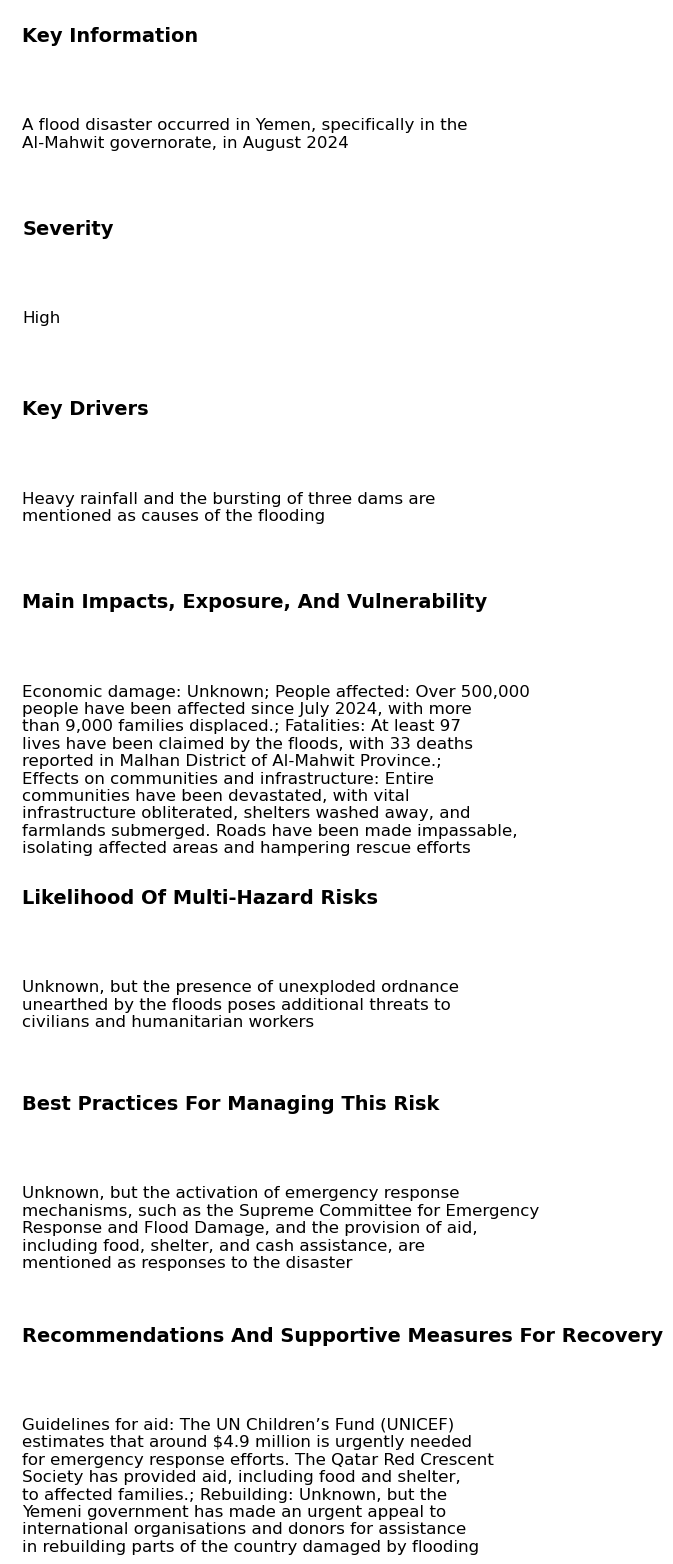

In [7]:
plot_factsheet_clean(
    distory,
    disno="2024-0649-YEM",
    wrap_width=55,          # a little wider because the figure is tall
    figsize=(8, 11),        # portrait‑style rectangle (fits PowerPoint slides)
    save_path="./data/factsheet_2024-0649-YEM.png"
)

In [8]:
source, relations, target = list(zip(*eval(distory[distory["DisNo."]=="2015-0232-PAK"]["llama graph"].iloc[0])))
kg_df = pd.DataFrame({'source': source, 'target': target, 'edge': relations})

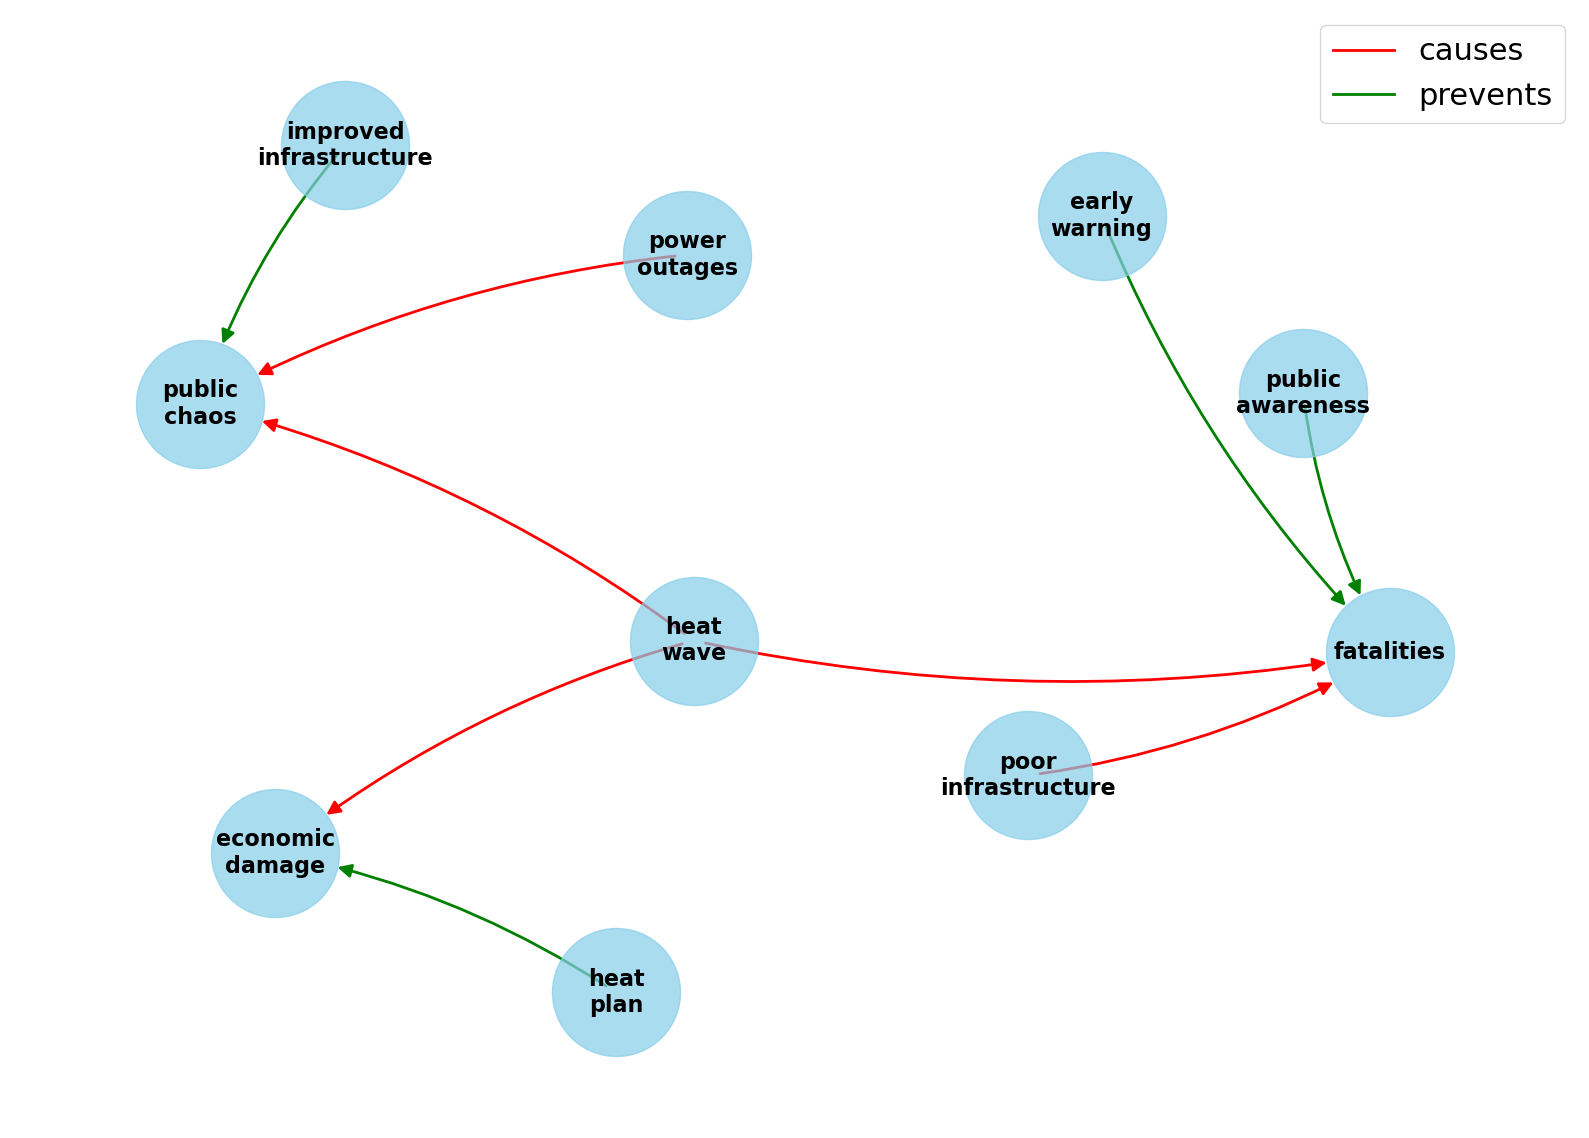

In [9]:
plot_cgraph(kg_df)

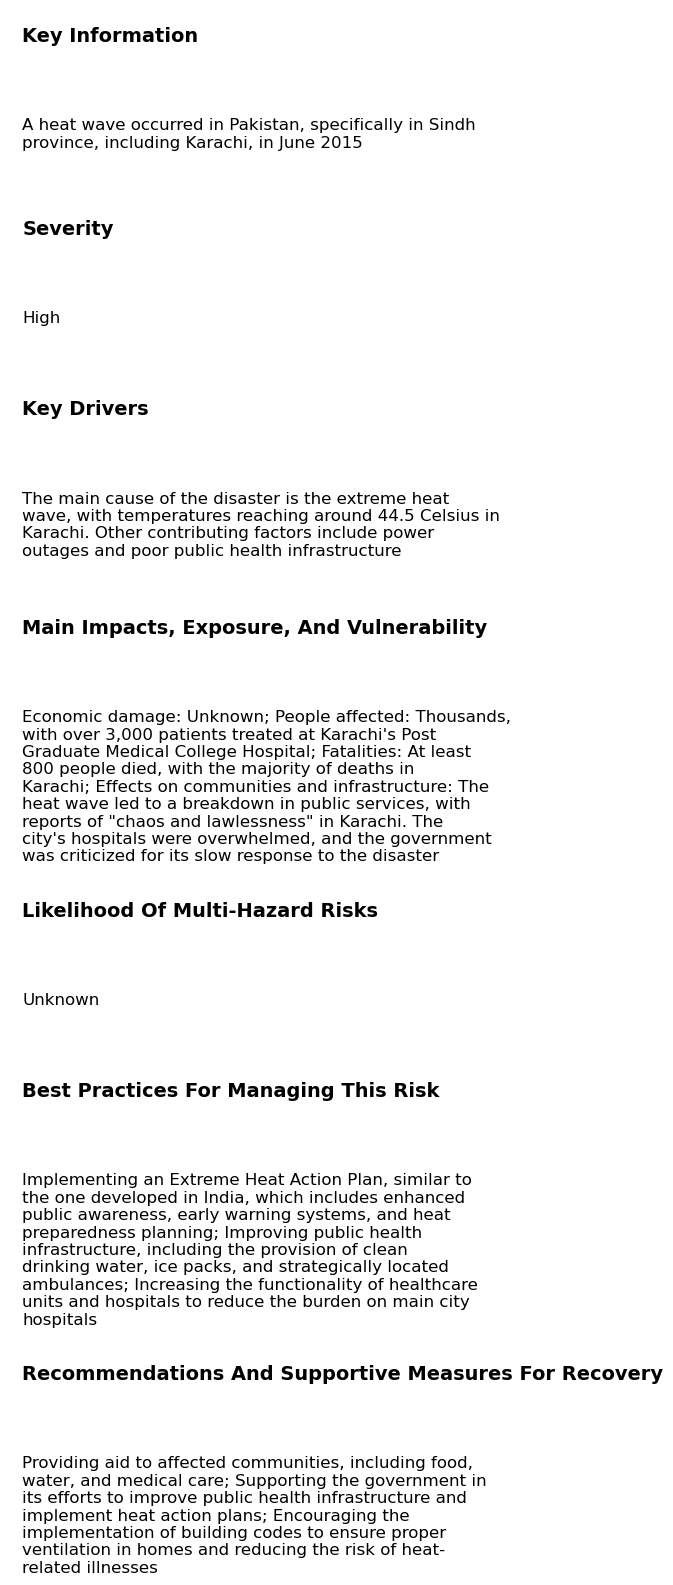

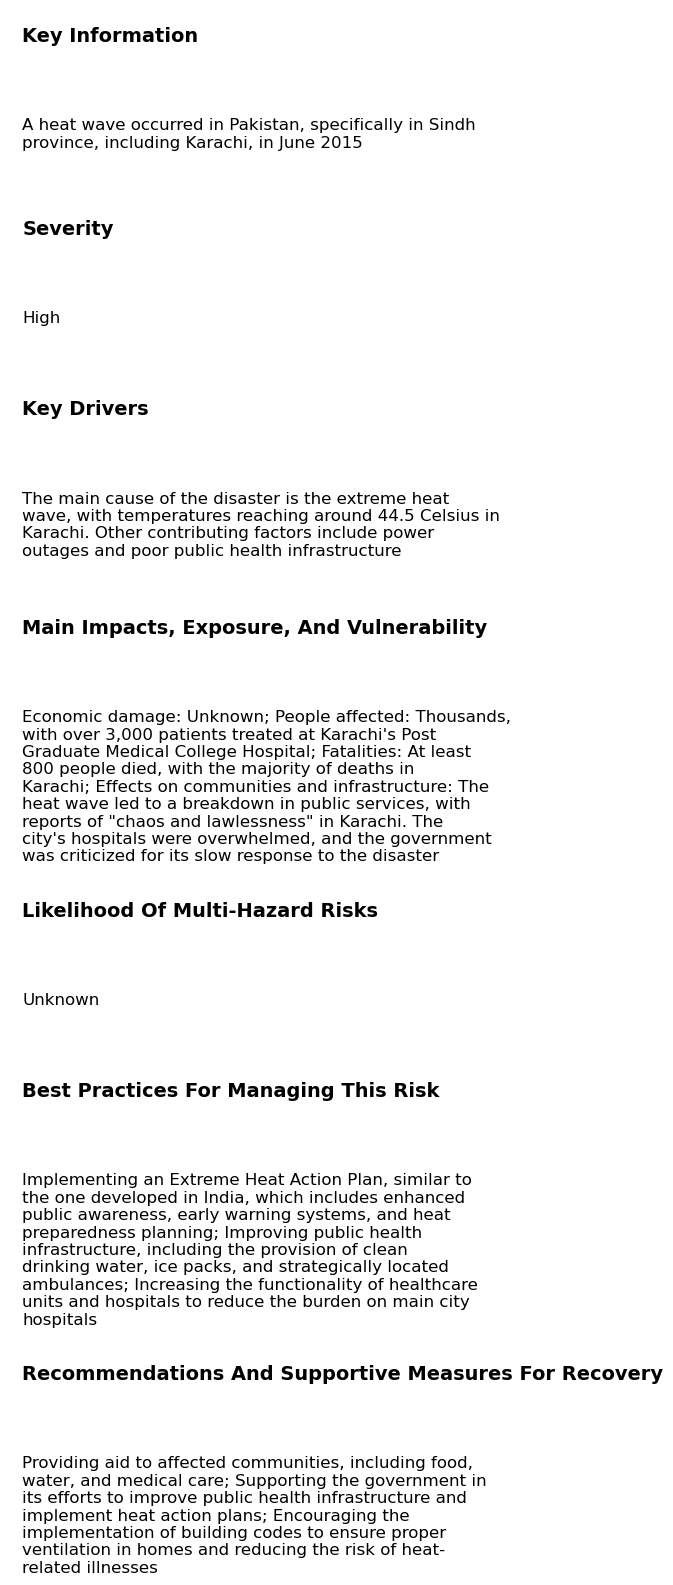

In [11]:
plot_factsheet_clean(
    distory,
    disno="2015-0232-PAK",
    wrap_width=55,          # a little wider because the figure is tall
    figsize=(8, 11),        # portrait‑style rectangle (fits PowerPoint slides)
    save_path="./data/factsheet_2015-0232-PAK.png"
)